In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy import stats
import seaborn as sns

import os 
import sys

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [323]:
root_dir = os.path.dirname(os.getcwd())

item_path = os.path.join(root_dir, "data_files", "fct_order_items.csv")
order_items = pd.read_csv(item_path)

customer_path = os.path.join(root_dir, "data_files", "dim_customers.csv")
customers = pd.read_csv(customer_path)

product_path = os.path.join(root_dir, "data_files", "dim_products.csv")
products = pd.read_csv(product_path)

# 1. Overal exploration

### 1.1 Check overview

In [324]:
def overview_check(df):
    print(f"Number of rows: {len(df)}")
    print(f"Number of columns: {len(df.columns.tolist())}")
    print(f"Column list: {df.columns.tolist()}")
    print("\nSample rows:")

    return df.head()

In [325]:
overview_check(order_items)

Number of rows: 10000
Number of columns: 8
Column list: ['brand', 'item_id', 'gross_item_value', 'order_date', 'order_datetime', 'product_id', 'order_id', 'customer_id']

Sample rows:


,brand,item_id,gross_item_value,order_date,order_datetime,product_id,order_id,customer_id
0,Brand 1,1370486,21.50,1/1/2024,2024-01-01T10:29:14,2077,1229709,5.800000e+18
1,Brand 2,3794133,4.38,1/1/2024,2024-01-01T23:30:21,119,753517,8.210000e+18
2,Brand 3,17037113,40.50,1/1/2024,2024-01-01T13:42:54.547000,5145,2994406,1.150000e+18
3,Brand 4,17037214,45.91,1/1/2024,2024-01-01T14:50:30.140000,17013,2994429,2.960000e+18
4,Brand 2,3792949,5.05,1/1/2024,2024-01-01T06:56:35,1095,753292,6.720000e+18


In [326]:
overview_check(customers)

Number of rows: 7847
Number of columns: 3
Column list: ['customer_id', 'country', 'state']

Sample rows:


,customer_id,country,state
0,1.270000e+18,AE,Other
1,6.690000e+18,AE,Other
2,2.320000e+18,AG,Other
3,5.340000e+18,AT,Other
4,7.700000e+18,AU,Other


In [327]:
overview_check(products)

Number of rows: 3115
Number of columns: 2
Column list: ['product_id', 'product_group']

Sample rows:


,product_id,product_group
0,1407,Other
1,1673,Other
2,1687,Other
3,1709,Other
4,1743,Other


**Interpretation**
- Column names are consistent across the tables,  no need to modify
- order_items table can be merged with customers table on customer_id, and can be merged with products table on product_id. However, before merging, we need to check data quality

### 1.2 Column type

In [328]:
order_items.dtypes.to_frame("dtype")

,dtype
brand,object
item_id,int64
gross_item_value,float64
order_date,object
order_datetime,object
product_id,int64
order_id,int64
customer_id,float64


In [329]:
customers.dtypes.to_frame("dtype")

,dtype
customer_id,float64
country,object
state,object


In [330]:
products.dtypes.to_frame("dtype")

,dtype
product_id,int64
product_group,object


**Interpretation**
- Every the data type matches expectation well, no need to modify

### 1.3 Descriptive statistics

In [331]:
order_items['gross_item_value'].describe()

count    10000.000000
mean        30.661318
std        200.365242
min         -2.860000
25%          4.787500
50%         12.480000
75%         24.122500
max      15064.350000
Name: gross_item_value, dtype: float64

In [332]:
order_items[order_items["gross_item_value"] < 0.0].sort_values("order_id")

,brand,item_id,gross_item_value,order_date,order_datetime,product_id,order_id,customer_id
2771,Brand 2,3819486,-2.86,1/16/2024,2024-01-16T09:55:32,877,758188,7.590000e+18
5066,Brand 2,3845945,-0.15,1/30/2024,2024-01-30T10:46:03,1139,763240,6.130000e+18
8667,Brand 2,3887670,-0.20,2/22/2024,2024-02-22T11:15:46,712,770790,7.730000e+18
3451,Brand 1,1401749,-2.06,1/20/2024,2024-01-20T06:45:59,918,1235470,4.090000e+18
5257,Brand 1,1417971,-0.56,1/31/2024,2024-01-31T11:51:06,807,1238590,3.140000e+18


In [333]:
order_items[order_items["gross_item_value"] == 0.0] 

,brand,item_id,gross_item_value,order_date,order_datetime,product_id,order_id,customer_id
175,Brand 3,17038263,0.0,1/2/2024,2024-01-02T08:54:57.983000,12082,2994631,7.590000e+18
206,Brand 2,3794480,0.0,1/2/2024,2024-01-02T08:33:23,1156,753568,6.690000e+18
253,Brand 2,3794878,0.0,1/2/2024,2024-01-02T12:29:26,985,753652,7.950000e+18
274,Brand 3,17038704,0.0,1/2/2024,2024-01-02T12:36:04.177000,11489,2994723,1.720000e+18
282,Brand 4,17038365,0.0,1/2/2024,2024-01-02T09:53:00.470000,15060,2994651,3.220000e+18
...,...,...,...,...,...,...,...,...
9510,Brand 1,1463703,0.0,2/27/2024,2024-02-27T13:38:36,360,1246496,6.810000e+18
9697,Brand 2,3899805,0.0,2/28/2024,2024-02-28T08:18:18,706,772802,7.200000e+18
9736,Brand 2,3899925,0.0,2/28/2024,2024-02-28T09:20:09,839,772821,6.560000e+17
9785,Brand 2,3899923,0.0,2/28/2024,2024-02-28T09:20:09,583,772821,6.560000e+17


**Interpretation**
- Gross item value has a pretty large standard deviation (=2000)
- Its lowest values is negative which is extraodinary for item price
- Its highest value is dramatically high comparing to the mean (15,064$ >>> 30.66$)
- **Caution**: 5 order items have negative value, 92 order items have 0.0 value -> need to investigate whether it is data entry error or valid data

# 2. Check data quality & clean
* This stage is needed before merging datasets to generate the master data

### 2.1 Categorical data standardization

In [334]:
def standardize_categorical_data(df, categorical_cols):
    num_cols_cleaned = 0
    for col in categorical_cols:
        if col in df.columns and df[col].dtype == object:
            before = df[col].nunique(dropna=True)
            df[col] = df[col].str.strip().str.title()
            after = df[col].nunique(dropna=True)
            if before != after:
                print(f"  {col}: {before} to {after} distinct values (case-folding merged some)")
                num_cols_cleaned += 1
                
    if num_cols_cleaned == 0:
        print("All categorical columns are already standard, no need to clean at all")
    else:
        print(
            f"Standardized {num_cols_cleaned} categorical columns ! Categorical variable standardization done !"
        )

In [335]:
standardize_categorical_data(order_items, ['brand'])

All categorical columns are already standard, no need to clean at all


In [336]:
standardize_categorical_data(products, ['product_group'])

All categorical columns are already standard, no need to clean at all


In [337]:
standardize_categorical_data(customers, ['country','state'])

All categorical columns are already standard, no need to clean at all


### 2.1 Missing value 

#### 2.1.1 Detect missing value

In [338]:
order_items.isnull().sum()

brand               0
item_id             0
gross_item_value    0
order_date          0
order_datetime      0
product_id          0
order_id            0
customer_id         0
dtype: int64

In [339]:
products.isnull().sum()

product_id       0
product_group    0
dtype: int64

In [340]:
customers.isnull().sum()

customer_id    0
country        0
state          0
dtype: int64

**Interpretation**
- There is no missing values in order_items, products and customers tables

### 2.2  Duplicate value

#### 2.2.1 Detect duplicate value

In [341]:
def check_duplication(df, primary_key):
    # Full-row duplicates
    n_full_dups = df.duplicated().sum()
    print(f"Full-row duplicates   : {n_full_dups} : {n_full_dups/len(df):.2f} %")

    # Duplicate primary key
    if primary_key: 
        n_id_dups = df.duplicated(subset=[primary_key]).sum()
        print(f"Duplicate {primary_key}: {n_id_dups}")

In [342]:
check_duplication(order_items, 'item_id')

Full-row duplicates   : 0 : 0.00 %
Duplicate item_id: 0


In [343]:
check_duplication(products, 'product_id')

Full-row duplicates   : 0 : 0.00 %
Duplicate product_id: 0


In [344]:
check_duplication(customers, 'customer_id')

Full-row duplicates   : 925 : 0.12 %
Duplicate customer_id: 6397


In [345]:
# Example of duplicate ID of 5.340000e+18
customers[customers['customer_id'] == 5.340000e+18]

,customer_id,country,state
3,5.340000e+18,At,Other
603,5.340000e+18,Us,Ca
676,5.340000e+18,Us,Ca
1892,5.340000e+18,Us,Ga
2554,5.340000e+18,Us,Il
3972,5.340000e+18,Us,Mo
5841,5.340000e+18,Us,Pa
6154,5.340000e+18,Us,Pa
6681,5.340000e+18,Us,Tx
7290,5.340000e+18,Us,Va


**Interpretation**
- There is no duplication in order_items and products
- There are 925 duplicate rows (12% data size) in customers, for full-row duplicates, we remove by default
- There are 6,397 duplicate customer IDs. For each set of duplicates, we retain a single record by selecting the one with the highest alphabetical values for both country and state.

#### 2.2.2 Clean duplicate value

In [346]:
def drop_duplication(df, id_col=None, sorted_col=None, ascending=False):
    n_before = len(df)

    # Remove full-row duplicates
    df = df.drop_duplicates()

    # Handle duplicate IDs with multi-column sorting
    if id_col and sorted_col:
        # Ensure sorted_col is a list
        if isinstance(sorted_col, str):
            sorted_col = [sorted_col]
        
        # Allow ascending to be bool or list (same length as sorted_col)
        df = (
            df.sort_values(by=sorted_col, ascending=ascending)
              .drop_duplicates(subset=[id_col], keep="first")
        )

    print(f"\nRows before: {n_before:,}  →  after dedup: {len(df):,}  (removed {n_before - len(df):,})")
    
    return df

In [347]:
customers = drop_duplication(customers, id_col = "customer_id", sorted_col=["country", "state"])


Rows before: 7,847  →  after dedup: 1,450  (removed 6,397)


In [348]:
check_duplication(customers, 'customer_id')

Full-row duplicates   : 0 : 0.00 %
Duplicate customer_id: 0


### 2.3 Cardinallity 

In [349]:
def cardinality_check(df, columns):
    results = []

    for col in columns:
        if col in df.columns:
            results.append(
                {
                    "column": col,
                    "unique_values": df[col].nunique(dropna=False),
                }
            )

    result_df = pd.DataFrame(results).sort_values(by="unique_values", ascending=False)

    print("\nCardinality Check Table:\n")

    return result_df

In [350]:
print(f"Number of rows in order_items table: {len(order_items)}")
cardinality_check(order_items, order_items.columns)

Number of rows in order_items table: 10000

Cardinality Check Table:



,column,unique_values
1,item_id,10000
6,order_id,8744
4,order_datetime,8742
2,gross_item_value,4170
5,product_id,3115
7,customer_id,1450
3,order_date,60
0,brand,7


In [351]:
print(f"Number of rows in products table: {len(products)}")
cardinality_check(products, products.columns)

Number of rows in products table: 3115

Cardinality Check Table:



,column,unique_values
0,product_id,3115
1,product_group,11


In [352]:
print(f"Number of rows in customers table: {len(customers)}")
cardinality_check(customers, customers.columns)

Number of rows in customers table: 1450

Cardinality Check Table:



,column,unique_values
0,customer_id,1450
2,state,54
1,country,7


**Interpretation**
- Primary key identification:
    - item_id is the primary key of order_items table
    - product_id is the primary key of products table
    - customer_id is the primary key of products table
- Potential merging pattern
    - count unqiue values of customer_id on order_items table is equal to that of customer_id on customers table, we can merge order_items and customers using customer_id
    - count unqiue values of product_id on order_items table is equal to that of product_id on products table, we can merge order_items and products using product_id 

### 2.4 Outliers

#### 2.4.1 Detect outliers
* 3 main ways to detect outliers: Percentile-based method, Z-score method and visual check

In [353]:
def outlier_analysis(df, numeric_cols, n_cols=4):
    outlier_summary = []
    for col in numeric_cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        z = np.abs(stats.zscore(s))
        n_z = (z > 3).sum()
        outlier_summary.append(
            {
                "column": col,
                "mean": s.mean(),
                "median": s.median(),
                "std": s.std(),
                "min": s.min(),
                "max": s.max(),
                "IQR_low": lo,
                "IQR_high": hi,
                "n_IQR_outliers": n_out,
                "pct_IQR_outliers": round(n_out / len(s) * 100, 2),
                "n_zscore>3": n_z,
            }
        )
    
    n_cols = n_cols
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, numeric_cols):
        df[col].dropna().plot.box(ax=ax, color="steelblue")
        ax.set_title(col)

    # Hide any unused subplots
    for ax in axes[len(numeric_cols) :]:
        ax.set_visible(False)

    plt.suptitle("Outlier Detection — Box Plots", y=1.02)
    plt.tight_layout()
    plt.show()

    outlier_df = pd.DataFrame(outlier_summary)
    print("=== Outlier Summary ===")
    return outlier_df

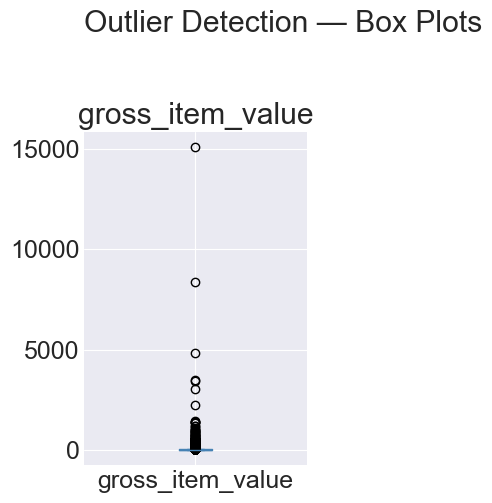

=== Outlier Summary ===


,column,mean,median,std,min,max,IQR_low,IQR_high,n_IQR_outliers,pct_IQR_outliers,n_zscore>3
0,gross_item_value,30.661318,12.48,200.365242,-2.86,15064.35,-24.215,53.125,883,8.83,32


In [354]:
outlier_analysis(order_items, ['gross_item_value'], n_cols=2)

**Interpretation**
- Negative outliers: Negative min price
- Extremely high value outliers: Mean is significantly different to median, due to the outliers from max values 
- Statistic test:
    - Result from Percentile-based method is significantly different to Z-score method
    - Result from visual check (7-8 dots) align with Percentile-based method more -> trust Percentile-based method because z-score method need condition of normal distribution
- But to make sure whether these are outliers, we should investigate more accounting features from products and customers tables (handle at the end of notebook)

### 2.5 Non-positive gross item values

#### 2.5.1 Handle negative gross item values

In [355]:
# Original negative rows from orders
original_negative_rows = order_items[order_items["gross_item_value"] < 0].sort_values("order_id")
original_negative_rows

,brand,item_id,gross_item_value,order_date,order_datetime,product_id,order_id,customer_id
2771,Brand 2,3819486,-2.86,1/16/2024,2024-01-16T09:55:32,877,758188,7.590000e+18
5066,Brand 2,3845945,-0.15,1/30/2024,2024-01-30T10:46:03,1139,763240,6.130000e+18
8667,Brand 2,3887670,-0.20,2/22/2024,2024-02-22T11:15:46,712,770790,7.730000e+18
3451,Brand 1,1401749,-2.06,1/20/2024,2024-01-20T06:45:59,918,1235470,4.090000e+18
5257,Brand 1,1417971,-0.56,1/31/2024,2024-01-31T11:51:06,807,1238590,3.140000e+18


**Potential reason**
- Case 1: Discount Adjustment for the order: sounds reasonable because the values are closed to 0$, then there should be at least 1 positive order item elsewhere within the same customer_id
- Case 2: Refunding amount for another order: then there should be a positive number of the same amount elsewhere within the same customer_id
- Case 3: Data entry/ELT error: If either of those cases, with the given bussiness knowledge, we just can assume it is error and drop it

In [356]:
# Investigate case 1: Discount: Do negative gross_item_value items share order_ids with any positive gross_item_value items?
order_ids = original_negative_rows["order_id"].unique()
orders[orders["order_id"].isin(order_ids)]

,brand,item_id,gross_item_value,order_date,order_datetime,product_id,order_id,customer_id
2771,Brand 2,3819486,-2.86,1/16/2024,2024-01-16T09:55:32,877,758188,7.590000e+18
3451,Brand 1,1401749,-2.06,1/20/2024,2024-01-20T06:45:59,918,1235470,4.090000e+18
5066,Brand 2,3845945,-0.15,1/30/2024,2024-01-30T10:46:03,1139,763240,6.130000e+18
5257,Brand 1,1417971,-0.56,1/31/2024,2024-01-31T11:51:06,807,1238590,3.140000e+18
8667,Brand 2,3887670,-0.20,2/22/2024,2024-02-22T11:15:46,712,770790,7.730000e+18


In [357]:
# Investigation case 2: Refunding: Do negative gross_item_value items share customer_ids with the same positive gross_item_value items?

negatives = order_items[order_items['gross_item_value'] < 0].copy()
positives = order_items[order_items['gross_item_value'] > 0].copy()

# Create the match key as an actual column
positives["neg_value"] = positives["gross_item_value"] * -1
negatives["abs_value"] = negatives["gross_item_value"].abs()

merged = pd.merge(
    negatives,
    positives,
    left_on=["customer_id", "abs_value"],
    right_on=["customer_id", "neg_value"],
    how="left",
    indicator=True
)

merged

,brand_x,item_id_x,gross_item_value_x,order_date_x,order_datetime_x,product_id_x,order_id_x,customer_id,abs_value,brand_y,item_id_y,gross_item_value_y,order_date_y,order_datetime_y,product_id_y,order_id_y,neg_value,_merge
0,Brand 2,3819486,-2.86,1/16/2024,2024-01-16T09:55:32,877,758188,7.590000e+18,2.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,Brand 1,1401749,-2.06,1/20/2024,2024-01-20T06:45:59,918,1235470,4.090000e+18,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2,Brand 2,3845945,-0.15,1/30/2024,2024-01-30T10:46:03,1139,763240,6.130000e+18,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,Brand 1,1417971,-0.56,1/31/2024,2024-01-31T11:51:06,807,1238590,3.140000e+18,0.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,Brand 2,3887670,-0.20,2/22/2024,2024-02-22T11:15:46,712,770790,7.730000e+18,0.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


**Interpretation**
- Case 1: Considering for the same order_id, negative value order doesn't appears as positive elsewhere, then we conclude that this is not the discount adjustment case
- Case 2:onsidering for the same customer_id, negative value order doesn't appears as the same number of positive elsewhere, then we conclude that this is not the refunding case
- Then with limited information, we conclude that this is data error then we can drop 5 negative gross_item_value rows

In [358]:
order_items_dropped = order_items[order_items["gross_item_value"] >= 0].copy()

#### 2.5.2 Handle zero gross item values

In [359]:
merged_df = pd.merge(
    order_items_dropped,          # left table
    products,        # right table
    how="left",      # keep all orders, add product info
    on="product_id"  # column to join on
)

zero_df = merged_df[merged_df["gross_item_value"] == 0.0]

In [360]:
def plot_value_counts_grid(
    df, 
    columns, 
    n_rows=2, 
    n_cols=2, 
    figsize=(15, 10),
    title="Zero Gross Item Value",
    max_bars=20  # ← added: prevents overcrowded y-axis for high-cardinality cols
):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if i >= n_rows * n_cols:
            break

        counts = (
            df[col]
            .value_counts()
            .head(max_bars)          # ← fix 4: limit bars for readability
            .reset_index()           # ← fix 3: use new seaborn-friendly format
        )
        counts.columns = [col, "count"]
        counts[col] = counts[col].astype(str)  # ← fix 1: always cast to string

        sns.barplot(
            data=counts,
            x="count",
            y=col,
            ax=axes[i],
            color="#4C9BE8"
        )
        axes[i].set_title(f"Distribution of {col}", pad=8)
        axes[i].set_xlabel("Count")
        axes[i].set_ylabel(col)

        # Annotate bar values
        for bar in axes[i].patches:
            axes[i].text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{int(bar.get_width())}",
                va="center", fontsize=8
            )

    # ← fix 2: use range(i+1, ...) safely — default i=-1 if loop never ran
    last_i = i if len(columns) > 0 else -1
    for j in range(last_i + 1, n_rows * n_cols):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)  # ← fix 4: y=1.02 prevents overlap
    plt.tight_layout()
    plt.show()

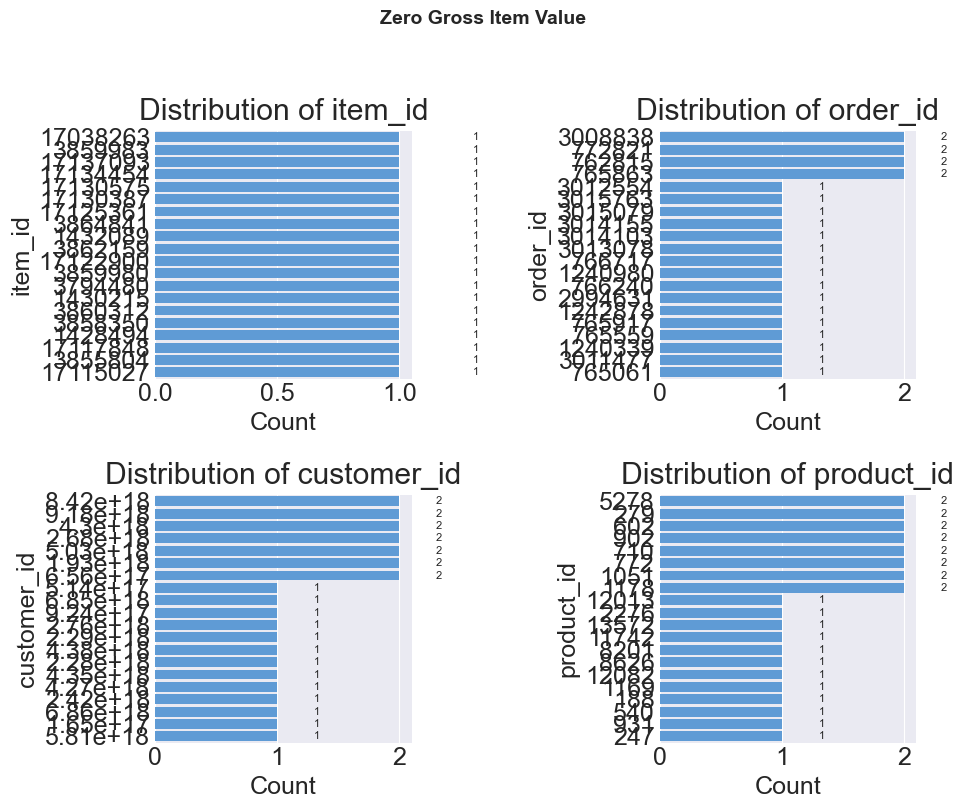

In [361]:
# plot id columns first 
columns_to_plot = ["item_id", "order_id","customer_id", "product_id"]
plot_value_counts_grid(zero_df, columns_to_plot, n_rows=2, n_cols=2, figsize=(10,8))


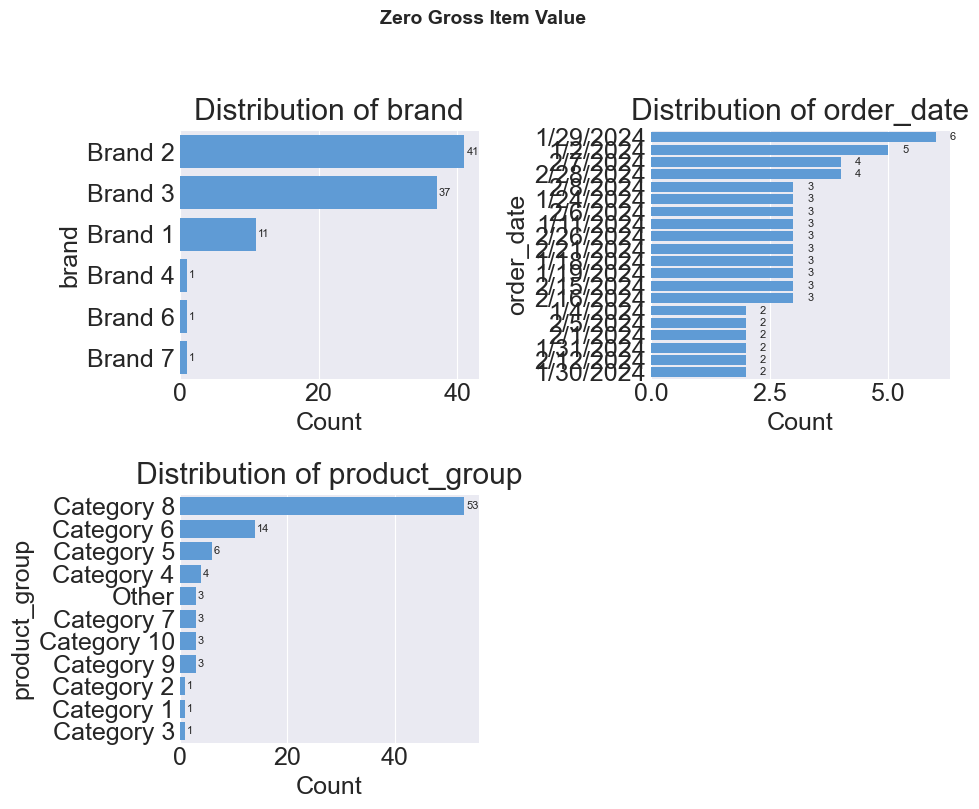

In [362]:
# plot id columns first 
columns_to_plot = ["brand", "order_date", "product_group"]
plot_value_counts_grid(zero_df, columns_to_plot, n_rows=2, n_cols=2, figsize=(10,8))

In [363]:
# Investigation: Check if zero-value items co-occur with normal items on the SAME order
zero_order_ids = zero_df["order_id"].unique()

co_occurring = order_items_dropped[
    (order_items_dropped["order_id"].isin(zero_order_ids)) & 
    (order_items_dropped["gross_item_value"] > 0)
]

print(f"Zero-value orders that also have paid items: {co_occurring['order_id'].nunique()}")
print(f"Total zero-value orders: {len(zero_order_ids)}")

Zero-value orders that also have paid items: 6
Total zero-value orders: 88


**Interpretation**
- Each `product_id`, `customer_id`, `order_id`, `item_id` just has 1 or 2 zero counts and was evenly distributed, so there is also no pattern or causes here
- Zeros are spread across every `order_date` with no clustering around a single day or week. Rules out a "flash sale" or "100% off campaign" event
- Brand 2, brand 3 has significantly higher zeros counts
- Cateogry 8 has significantly higher zeros counts
- The concentration is too strong to be random, plus there are 6 Zero-value orders that also have paid items; therefore, it is expected that **Brand 2 and Brand 3 bundle a Category 8 item as a free add-on. Each customer gets one — hence ~1 zero per customer. The wide date spread suggests it's an ongoing promotion, not a one-time event.**
- Since it doesn't contribute to the total revenue, be cautious when calculating Avg Gross Item Value (Question 5)

In [364]:
master_table = (
    order_items_dropped
    .merge(products,  on="product_id",  how="left")
    .merge(customers, on="customer_id", how="left")
)

# 3. EDA

### 3.1 Univariate EDA

In [365]:
def category_frequency(df, cols, top_n=15):
    for col in cols:
        vc = df[col].value_counts(dropna=False).head(top_n)
        fig, ax = plt.subplots(figsize=(12, 4))
        vc.plot.barh(ax=ax, color="steelblue", edgecolor="white")
        ax.invert_yaxis()
        ax.set_title(
            f"{col}  (top {top_n} of {df[col].nunique()} unique | null={df[col].isnull().mean():.1%})"
        )
        ax.set_xlabel("Count")
        total = len(df)
        for p in ax.patches:
            ax.annotate(
                f"{p.get_width() / total:.1%}",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha="left",
                va="center",
                fontsize=9,
            )
        plt.tight_layout()
        plt.show()

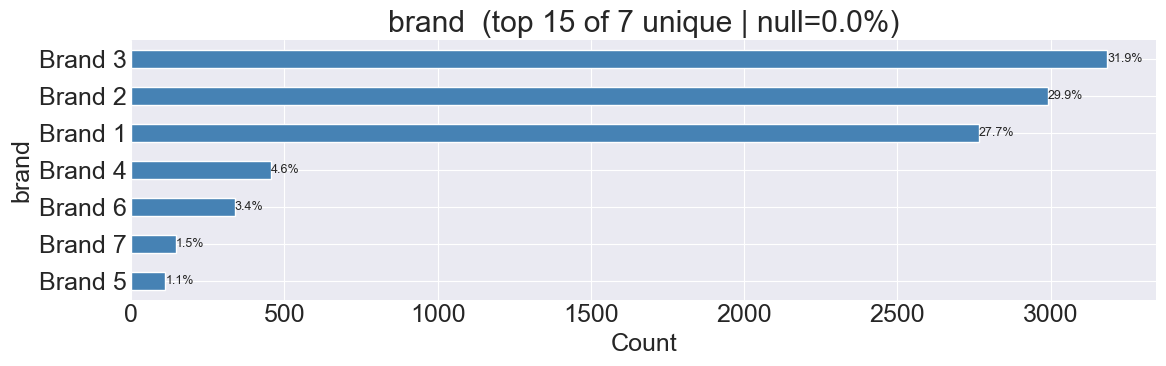

In [366]:
category_frequency(master_table, ["brand"])

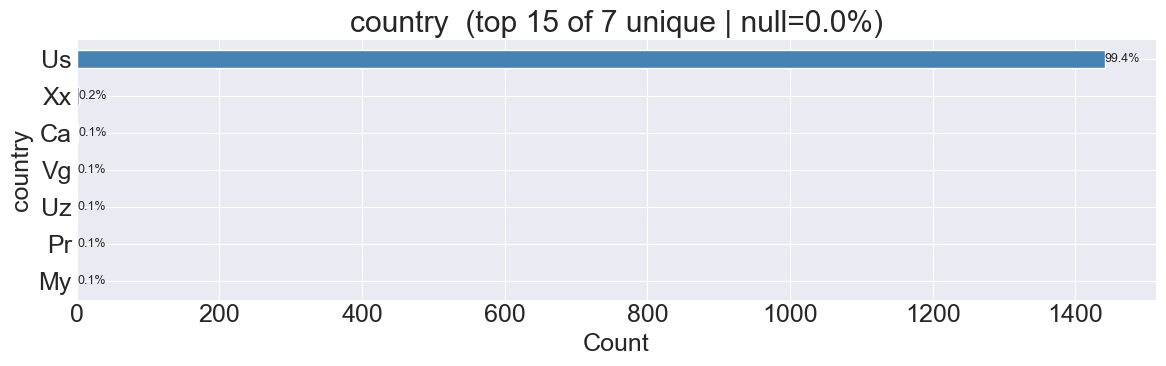

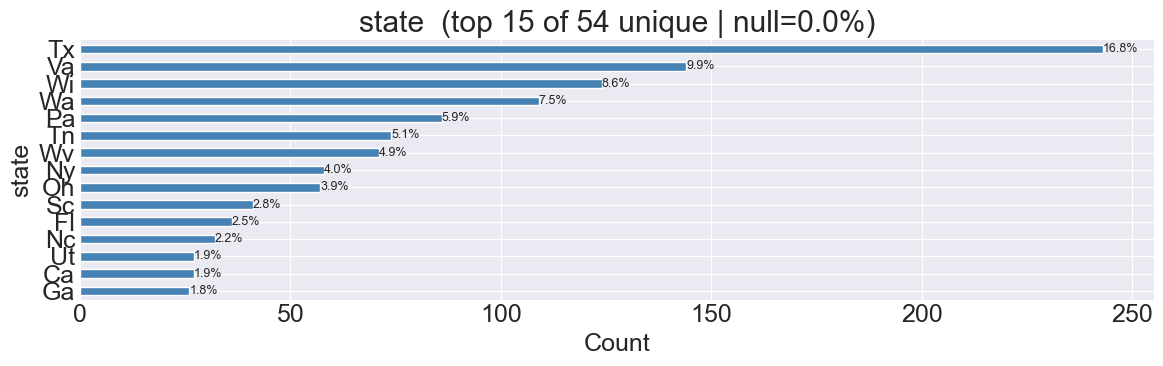

In [367]:
category_frequency(customers, ["country", "state"])

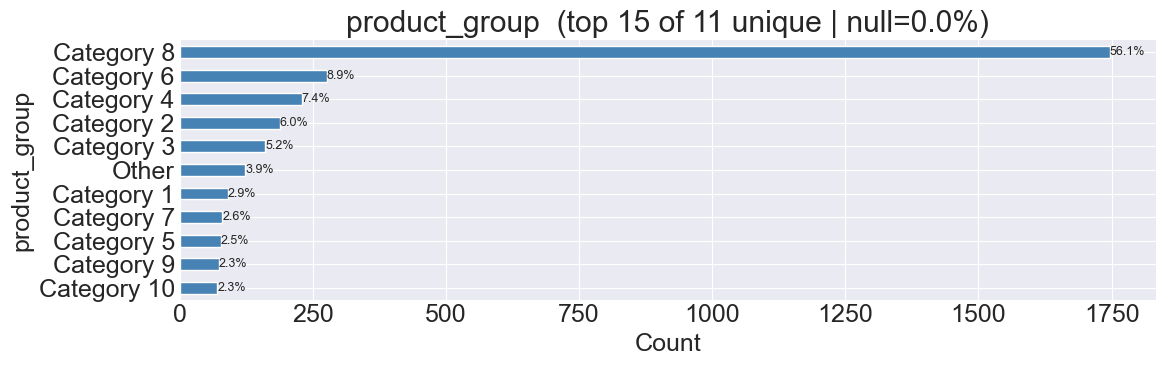

In [368]:
category_frequency(products, ["product_group"])

**Interpretation**
- Nearly 100% country feature is US, so it doesn't have distinguish power
- Cateogory 8 contributes the most in product type
- Texas came first in the number of order item origin
- Brand 3, 2, and 1 are leading in sales

### 3.2 Bivariate EDA

In [369]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

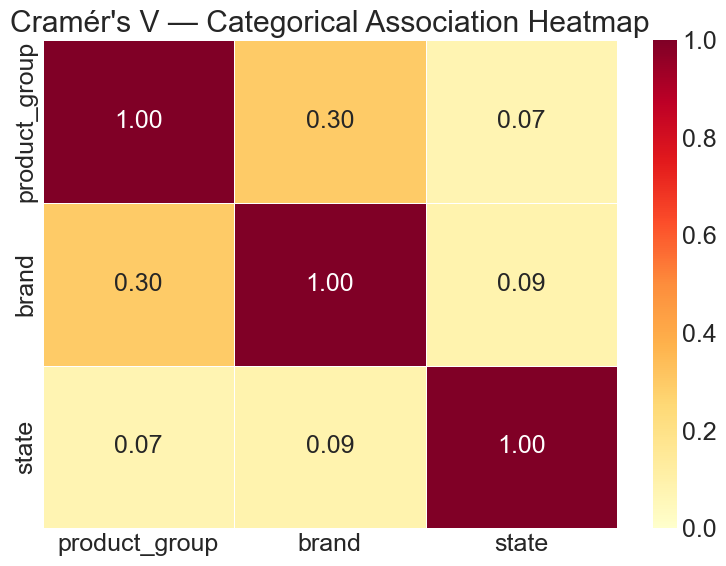

In [370]:
cat_subset = ["product_group", "brand", "state"]

if len(cat_subset) > 1:
    cv_matrix = pd.DataFrame(index=cat_subset, columns=cat_subset, dtype=float)
    for c1 in cat_subset:
        for c2 in cat_subset:
            if c1 == c2:
                cv_matrix.loc[c1, c2] = 1.0
            else:
                tmp = master_table[[c1, c2]].dropna()
                cv_matrix.loc[c1, c2] = cramers_v(tmp[c1], tmp[c2]) if len(tmp) > 10 else np.nan

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cv_matrix.astype(float),
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=1,
    )
    ax.set_title("Cramér's V — Categorical Association Heatmap")
    plt.tight_layout()
    plt.show()

**Interpretation**
- There are no correlation between state, brand and product (pair-wise) as every correlation < 0.5

# 4. Final checking step with merged table

### 4.1 Investigate outliers
* To see whether paying more than 2,000$ for an item is legit or not, we just need to answer: is the product `product_id` of that item normally sell at that high `gross_item_value`

In [371]:
extreme_df = master_table[master_table["gross_item_value"] > 2000].copy()

In [372]:
extreme_df[["gross_item_value", "product_id"]].sort_values("gross_item_value", ascending=False)

,gross_item_value,product_id
6119,15064.35,12080
5042,8345.35,11979
4934,4844.90,7615
7357,3481.35,13995
9584,3429.40,11424
1671,3029.21,15382
5842,2213.90,919


In [373]:
suspect_product_ids = extreme_df["product_id"].unique()

# ── Anomaly price lookup per product_id ──────────────────────────────────────
anomaly_prices = (
    extreme_df.groupby("product_id")["gross_item_value"]
    .apply(lambda x: sorted(x.round(2).tolist()))
    .reset_index()
    .rename(columns={"gross_item_value": "anomaly_sell_prices"})
)

# ── Normal price history per product_id ──────────────────────────────────────
product_price_profile = (
    master_table[master_table["product_id"].isin(suspect_product_ids)]
    .groupby("product_id")["gross_item_value"]
    .agg(
        times_sold="count",
        min_price="min",
        median_price="median",
        max_price="max",
        all_sell_prices=lambda x: sorted(x.round(2).tolist())
    )
    .reset_index()
)

# ── Merge anomaly prices alongside normal profile ─────────────────────────────
product_price_profile = product_price_profile.merge(
    anomaly_prices, on="product_id", how="left"
)

print(product_price_profile[[
    "product_id", "times_sold",
    "anomaly_sell_prices",
    "all_sell_prices"
]].to_string())

   product_id  times_sold anomaly_sell_prices                                                     all_sell_prices
0         919          10            [2213.9]  [3.48, 3.8, 4.45, 6.71, 11.31, 14.01, 15.38, 15.73, 17.45, 2213.9]
1        7615           2            [4844.9]                                                    [334.37, 4844.9]
2       11424           1            [3429.4]                                                            [3429.4]
3       11979           2           [8345.35]                                                    [50.27, 8345.35]
4       12080           3          [15064.35]                                          [314.13, 464.73, 15064.35]
5       13995           2           [3481.35]                                                    [18.94, 3481.35]
6       15382           5           [3029.21]                                 [3.3, 10.07, 19.33, 21.25, 3029.21]


**Interpretation**
- Only item with product_id = 11424 might be legit because for other item as it is the only item sold and has only 1 price
- For other product,there is a hugh differennce between the anolmaly sold price and the normal price 
- **Solution**: We drop anolmaly sold price at `product_id` =  [919, 7615, 11979, 12080, 13995, 15382]

In [374]:
master_table_dropped = master_table[
    ~master_table["product_id"].isin([919, 7615, 11979, 12080, 13995, 15382])
]

In [375]:
master_table_dropped.to_csv("master_table.csv", index=False)